In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


DATA LOAD & FILTERING

In [2]:
file_path = r'/content/preprocessed_demand_data (1) (2).csv'
df = pd.read_csv(file_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [3]:
print(f"Available Hubs: {df['Hub'].unique()}")
selected_hub = df['Hub'].unique()[0]  # First hub-ah automatic-ah yedukuroam
print(f"Filtering data for: {selected_hub}")

sub_df = df[df['Hub'] == selected_hub].copy()

Available Hubs: ['Bengaluru_Hub' 'Kolkata_Hub' 'Hyderabad_Hub' 'Delhi_Hub' 'Chennai_Hub'
 'Mumbai_Hub']
Filtering data for: Bengaluru_Hub


In [4]:
sub_df = sub_df.set_index('Date').asfreq('D')
sub_df['OrderCount'] = sub_df['OrderCount'].interpolate(method='linear')

FEATURE SELECTION (Target and Exogenous)


In [5]:
target_col = 'OrderCount'

# External features that affect demand (Exogenous variables)
exog_cols = ['Holiday_Indicator_Encoded', 'Festival_Name_Encoded', 'IsWeekend']

# Fill any NaN in exog features caused by asfreq('D')
for col in exog_cols:
    sub_df[col] = sub_df[col].fillna(0)


TRAIN & TEST SPLIT

In [6]:
split_idx = int(len(sub_df) * 0.8)

train_df = sub_df.iloc[:split_idx]
test_df = sub_df.iloc[split_idx:]

y_train = train_df[target_col]
exog_train = train_df[exog_cols]

y_test = test_df[target_col]
exog_test = test_df[exog_cols]

SARIMAX MODEL SPECIFICATION & TRAINING

In [7]:
print("Training SARIMAX model... (This might take a moment)")

# (p,d,q) x (P,D,Q)s
# Trend orders (p,d,q): p=1 (lag 1), d=1 (differencing), q=1 (error lag)
# Seasonal orders (P,D,Q)s: s=7 (Weekly seasonality since DayOfWeek was top in LightGBM)
model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = model.fit(disp=False)
print(sarimax_result.summary())


Training SARIMAX model... (This might take a moment)
                                     SARIMAX Results                                     
Dep. Variable:                        OrderCount   No. Observations:                 1057
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -5871.852
Date:                           Mon, 20 Jul 2026   AIC                          11759.705
Time:                                   06:15:15   BIC                          11799.280
Sample:                               01-16-2021   HQIC                         11774.717
                                    - 12-08-2023                                         
Covariance Type:                             opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Holiday_Indicator_Encoded    22.6660   

PREDICTION & EVALUATION


In [8]:
y_pred = sarimax_result.forecast(steps=len(test_df), exog=exog_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- SARIMAX Model Evaluation ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")



--- SARIMAX Model Evaluation ---
RMSE: 156.9521
MAE: 106.3398
R2 Score: 0.3814


VISUALIZATION (Actual vs Predicted)

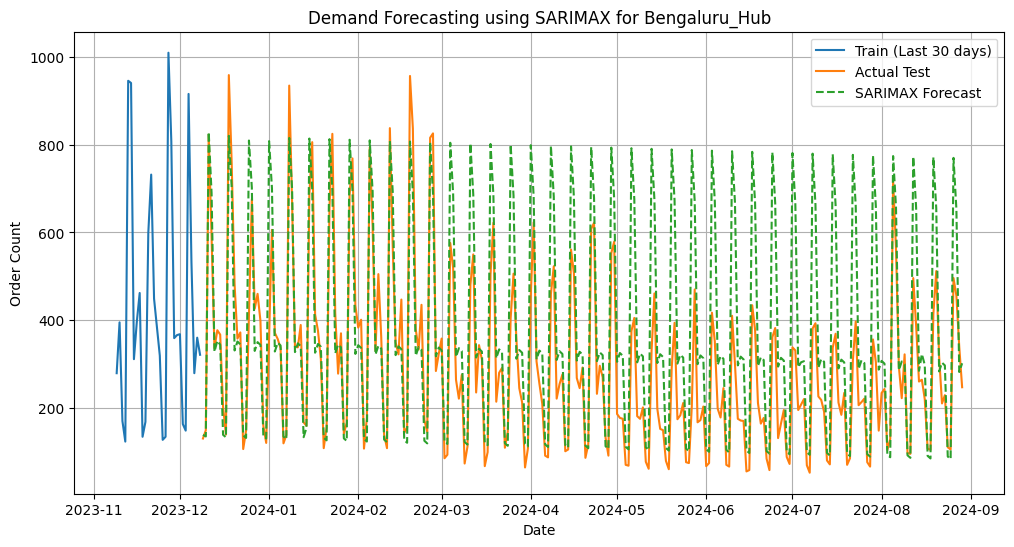

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(y_train.index[-30:], y_train.values[-30:], label='Train (Last 30 days)')
plt.plot(y_test.index, y_test.values, label='Actual Test')
plt.plot(test_df.index, y_pred, label='SARIMAX Forecast', linestyle='--')
plt.title(f'Demand Forecasting using SARIMAX for {selected_hub}')
plt.xlabel('Date')
plt.ylabel('Order Count')
plt.legend()
plt.grid(True)
plt.show()